# Handwritten Digit Classification - CNN vs MLP

In this project, I will train a CNN and an MLP on the MNIST dataset and compare their results. I will also test the CNN on my own handwritten digits.

## 1. Import Libraries

In [17]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
GPU: False


## 2. Load MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits from 0 to 9. Each image is 28x28 pixels.

I use ToTensor() to convert the images into tensors and scale pixel values from 0-255 to 0-1.

In [18]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_data))
print("Test images:", len(test_data))

Training images: 60000
Test images: 10000


## 3. Train, Validation and Test Split

I split the original training data into 54,000 training images and 6,000 validation images. The original 10,000 test images are kept separately for final evaluation.

Both CNN and MLP will use the same data split, batch size and number of epochs for a fair comparison.

In [19]:
torch.manual_seed(42)

train_ds, val_ds = random_split(
    train_data,
    [54000, 6000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_data))

Train: 54000
Validation: 6000
Test: 10000


## 4. Explore the Dataset

Before training the models, I will check the image shape, labels and pixel values. I will also display some MNIST images.

In [20]:
X, y = train_ds[0]

print("Image shape:", X.shape)
print("Label:", y)
print("Min pixel value:", X.min().item())
print("Max pixel value:", X.max().item())

Image shape: torch.Size([1, 28, 28])
Label: 6
Min pixel value: 0.0
Max pixel value: 1.0


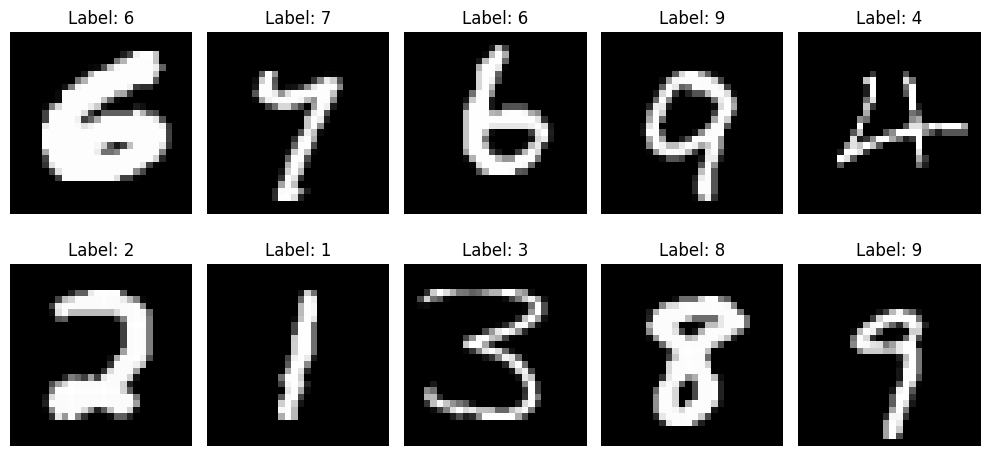

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    X, y = train_ds[i]

    ax.imshow(X.squeeze(), cmap="gray")
    ax.set_title(f"Label: {y}")
    ax.axis("off")

plt.tight_layout()
plt.show()

The images are 28x28 pixels with one grayscale channel. Pixel values are scaled to the range [0, 1], and the labels represent digits from 0 to 9.

## 5. CNN Model

I will build a CNN with two convolution and max-pooling blocks, followed by fully connected layers.

The convolution layers learn image patterns, while pooling reduces the image size. The final layers predict the digit from 0 to 9.

In [22]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.pool1(self.relu(self.conv1(X)))
        X = self.pool2(self.relu(self.conv2(X)))

        X = torch.flatten(X, 1)

        X = self.relu(self.fc1(X))
        X = self.fc2(X)

        return X

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn = CNN().to(device)

print(cnn)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


### CNN Architecture

| Layer | Output Shape | Purpose |
|---|---|---|
| Input | 1 × 28 × 28 | Grayscale MNIST image |
| Conv2d + ReLU | 32 × 28 × 28 | Learn simple image patterns |
| MaxPool2d | 32 × 14 × 14 | Reduce image size |
| Conv2d + ReLU | 64 × 14 × 14 | Learn more complex patterns |
| MaxPool2d | 64 × 7 × 7 | Reduce image size again |
| Flatten | 3136 | Convert feature maps into a vector |
| Linear + ReLU | 128 | Learn from extracted features |
| Linear | 10 | Output scores for digits 0–9 |

The CNN is trained from random initialization. No pretrained weights are used.

## 6. Train the CNN

I will train the CNN for 5 epochs using CrossEntropyLoss and Adam optimizer.

After each epoch, I will calculate training and validation loss and accuracy. I will save these results to plot the learning curves later.

In [24]:
epochs = 5
lr = 0.001

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=lr)

cnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [25]:
for epoch in range(epochs):

    cnn.train()

    train_loss = 0
    train_correct = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        output = cnn(X)
        loss = loss_fn(output, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        train_correct += (output.argmax(1) == y).sum().item()

    train_loss /= len(train_ds)
    train_acc = train_correct / len(train_ds)

    cnn.eval()

    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            output = cnn(X)
            loss = loss_fn(output, y)

            val_loss += loss.item() * X.size(0)
            val_correct += (output.argmax(1) == y).sum().item()

    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.2035 | Train Acc: 0.9376 | Val Loss: 0.0755 | Val Acc: 0.9782
Epoch 2/5 | Train Loss: 0.0537 | Train Acc: 0.9837 | Val Loss: 0.0680 | Val Acc: 0.9788
Epoch 3/5 | Train Loss: 0.0374 | Train Acc: 0.9879 | Val Loss: 0.0662 | Val Acc: 0.9802
Epoch 4/5 | Train Loss: 0.0271 | Train Acc: 0.9914 | Val Loss: 0.0404 | Val Acc: 0.9868
Epoch 5/5 | Train Loss: 0.0210 | Train Acc: 0.9936 | Val Loss: 0.0529 | Val Acc: 0.9858


## 7. CNN Training Curves

I will plot training and validation loss and accuracy to check how the CNN learns over 5 epochs.

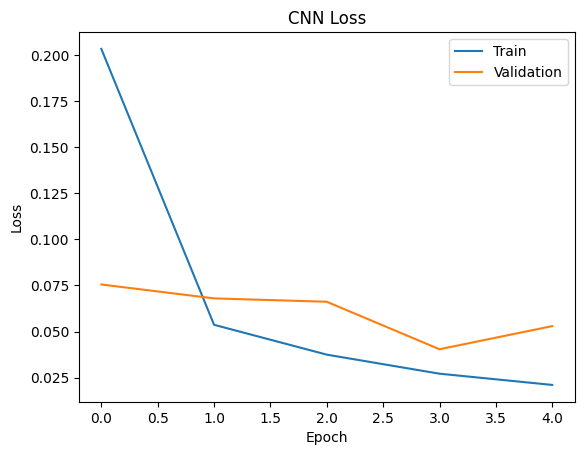

In [26]:
plt.plot(cnn_history["train_loss"], label="Train")
plt.plot(cnn_history["val_loss"], label="Validation")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

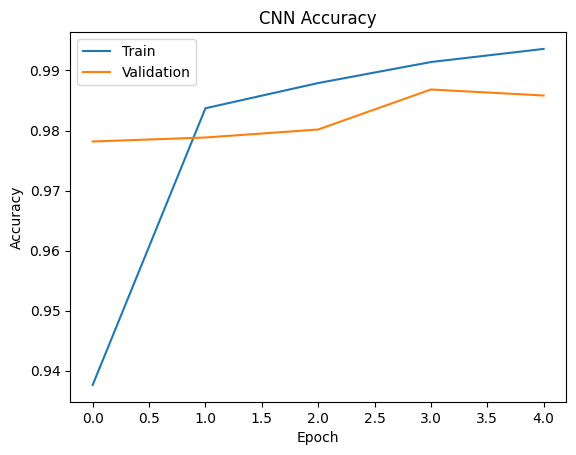

In [27]:
plt.plot(cnn_history["train_acc"], label="Train")
plt.plot(cnn_history["val_acc"], label="Validation")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The CNN reached 99.36% training accuracy and 98.58% validation accuracy after 5 epochs.

The highest validation accuracy was 98.68% at epoch 4. Training accuracy continued to increase, but validation accuracy slightly decreased in the last epoch. This may indicate mild overfitting.

## 8. MLP Baseline

I will train a simple MLP to compare it with the CNN.

The MLP uses fully connected layers without convolution or pooling. Both models will use the same dataset, data split, batch size, optimizer type, learning rate and number of epochs.

In [28]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, X):
        X = torch.flatten(X, 1)

        X = self.relu(self.fc1(X))
        X = self.relu(self.fc2(X))
        X = self.fc3(X)

        return X

In [29]:
mlp = MLP().to(device)

print(mlp)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


### MLP Architecture

| Layer | Output Shape |
|---|---|
| Input | 1 × 28 × 28 |
| Flatten | 784 |
| Linear + ReLU | 128 |
| Linear + ReLU | 64 |
| Linear | 10 |

The MLP takes the flattened image as input and predicts one of the 10 digit classes.

It is trained from random initialization without pretrained weights.

## 9. Train the MLP

I will train the MLP for 5 epochs using the same training and validation data as the CNN.

I will use CrossEntropyLoss and Adam with a learning rate of 0.001. I will track loss and accuracy for both training and validation.

In [30]:
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)

mlp_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [31]:
for epoch in range(epochs):

    mlp.train()

    train_loss = 0
    train_correct = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        mlp_optimizer.zero_grad()

        output = mlp(X)
        loss = loss_fn(output, y)

        loss.backward()
        mlp_optimizer.step()

        train_loss += loss.item() * X.size(0)
        train_correct += (output.argmax(1) == y).sum().item()

    train_loss /= len(train_ds)
    train_acc = train_correct / len(train_ds)

    mlp.eval()

    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            output = mlp(X)
            loss = loss_fn(output, y)

            val_loss += loss.item() * X.size(0)
            val_correct += (output.argmax(1) == y).sum().item()

    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    mlp_history["train_loss"].append(train_loss)
    mlp_history["train_acc"].append(train_acc)
    mlp_history["val_loss"].append(val_loss)
    mlp_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.3529 | Train Acc: 0.9006 | Val Loss: 0.1875 | Val Acc: 0.9448
Epoch 2/5 | Train Loss: 0.1456 | Train Acc: 0.9564 | Val Loss: 0.1439 | Val Acc: 0.9598
Epoch 3/5 | Train Loss: 0.0984 | Train Acc: 0.9706 | Val Loss: 0.1142 | Val Acc: 0.9645
Epoch 4/5 | Train Loss: 0.0745 | Train Acc: 0.9765 | Val Loss: 0.1046 | Val Acc: 0.9702
Epoch 5/5 | Train Loss: 0.0581 | Train Acc: 0.9821 | Val Loss: 0.1080 | Val Acc: 0.9668


## 10. CNN vs MLP Training Curves

I will compare the training and validation loss and accuracy of both models.

Both models were trained for 5 epochs using the same data split, batch size, optimizer type and learning rate.

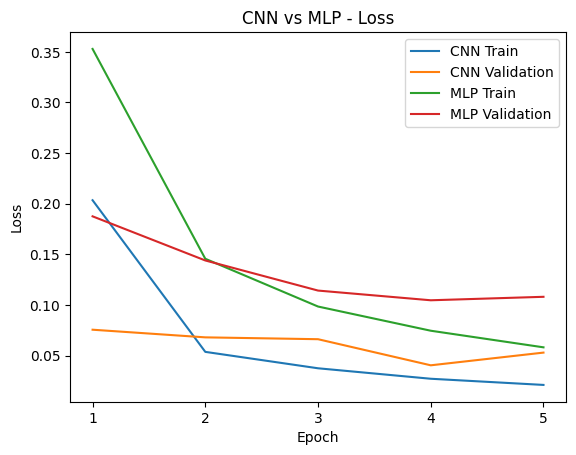

In [32]:
plt.plot(cnn_history["train_loss"], label="CNN Train")
plt.plot(cnn_history["val_loss"], label="CNN Validation")

plt.plot(mlp_history["train_loss"], label="MLP Train")
plt.plot(mlp_history["val_loss"], label="MLP Validation")

plt.title("CNN vs MLP - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(5), range(1, 6))
plt.legend()
plt.show()

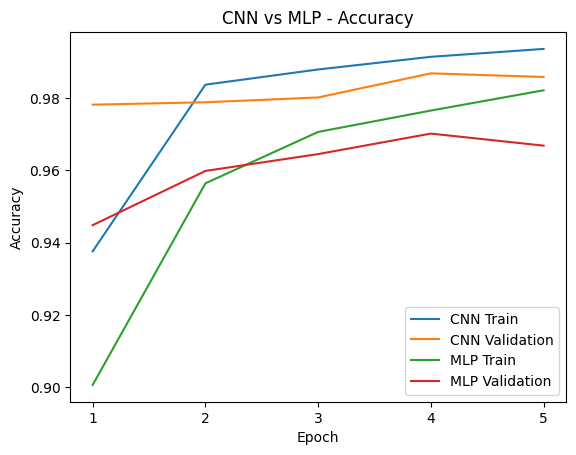

In [33]:
plt.plot(cnn_history["train_acc"], label="CNN Train")
plt.plot(cnn_history["val_acc"], label="CNN Validation")

plt.plot(mlp_history["train_acc"], label="MLP Train")
plt.plot(mlp_history["val_acc"], label="MLP Validation")

plt.title("CNN vs MLP - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(5), range(1, 6))
plt.legend()
plt.show()

### Comparison

The CNN reached 98.58% validation accuracy, while the MLP reached 96.68% after 5 epochs.

The CNN also had lower validation loss. This suggests that convolution and pooling helped the model learn useful spatial patterns from the handwritten images.

Both models showed a small decrease in validation accuracy during the last epoch, which may indicate mild overfitting.

## 11. Test Evaluation

I will evaluate both models on the same 10,000 test images.

The test set was not used during training or validation. I will compare the final test loss and accuracy of the CNN and MLP.

In [34]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            output = model(X)
            loss = loss_fn(output, y)

            total_loss += loss.item() * X.size(0)
            correct += (output.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

In [35]:
cnn_test_loss, cnn_test_acc = evaluate(cnn, test_loader)
mlp_test_loss, mlp_test_acc = evaluate(mlp, test_loader)

print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.2%}")

print()

print(f"MLP Test Loss: {mlp_test_loss:.4f}")
print(f"MLP Test Accuracy: {mlp_test_acc:.2%}")

CNN Test Loss: 0.0359
CNN Test Accuracy: 98.82%

MLP Test Loss: 0.0887
MLP Test Accuracy: 97.31%


### Test Results

| Model | Test Loss | Test Accuracy |
|---|---:|---:|
| CNN | 0.0359 | 98.82% |
| MLP | 0.0887 | 97.31% |

The CNN achieved 98.82% test accuracy, while the MLP achieved 97.31%.

The CNN performed better by 1.51 percentage points and also had lower test loss. This suggests that convolution and pooling help the model learn spatial patterns in handwritten digits more effectively than the plain MLP.

Both models were trained on the same data split for 5 epochs using Adam and the same learning rate.

## 12. Confusion Matrix

I will use a confusion matrix to check which digits the CNN predicts correctly and which digits it confuses most often.

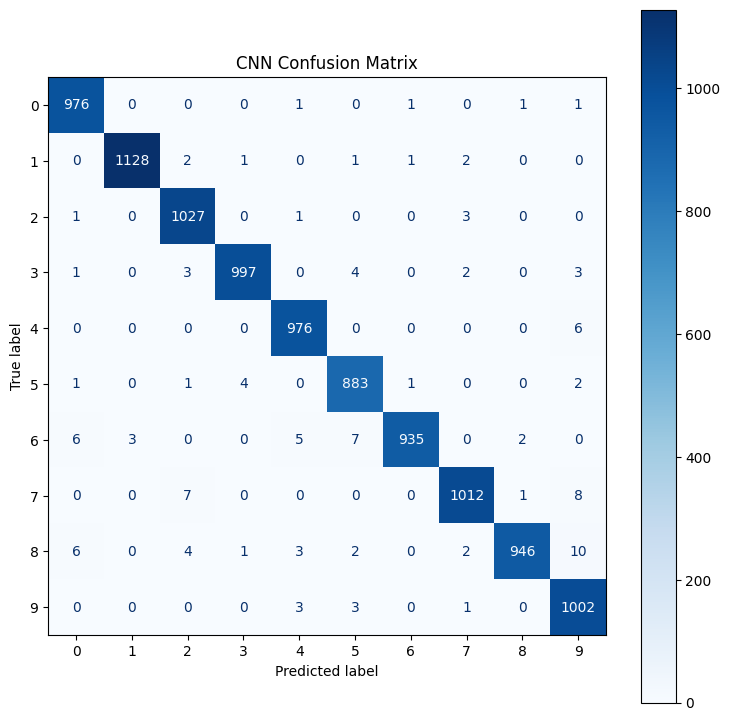

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

cnn.eval()

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)

        output = cnn(X)
        predictions = output.argmax(1)

        y_true.extend(y.numpy())
        y_pred.extend(predictions.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap="Blues", ax=ax)

plt.title("CNN Confusion Matrix")
plt.show()

In [39]:
cm_errors = cm.copy()

np.fill_diagonal(cm_errors, 0)

true_digit, predicted_digit = np.unravel_index(
    cm_errors.argmax(),
    cm_errors.shape
)

print("True digit:", true_digit)
print("Predicted digit:", predicted_digit)
print("Number of mistakes:", cm_errors[true_digit, predicted_digit])

True digit: 8
Predicted digit: 9
Number of mistakes: 10


### Confusion Matrix Results

The most confused digit pair was 8 and 9. The CNN predicted the digit 8 as 9 in 10 test images.

This may happen because some handwritten 8s have an unclear or incomplete lower loop, making them look similar to 9.

The confusion matrix helps identify specific mistakes that overall accuracy does not show.

## 13. Save and Reload the CNN

I will save the trained CNN weights and reload them into a new model instance. This allows me to make predictions without training the model again.

In [40]:
from pathlib import Path

Path("models").mkdir(exist_ok=True)
torch.save(cnn.state_dict(), "models/cnn_mnist.pth")

print("CNN model saved!")

CNN model saved!


## 14. Reload the CNN and Run Inference

I will load the saved weights into a new CNN instance and test it on an MNIST image without retraining.

In [41]:
loaded_cnn = CNN().to(device)

loaded_cnn.load_state_dict(
    torch.load("models/cnn_mnist.pth", map_location=device, weights_only=True)
)

loaded_cnn.eval()

print("Model loaded successfully!")

Model loaded successfully!


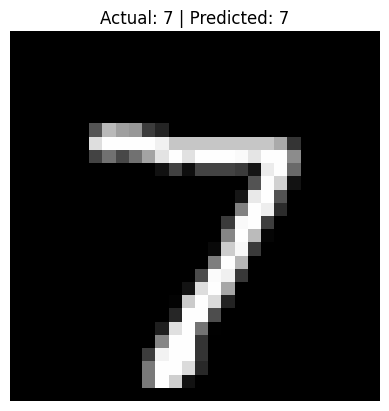

In [44]:
X, y = test_data[0]

with torch.no_grad():
    output = loaded_cnn(X.unsqueeze(0).to(device))
    prediction = output.argmax(1).item()

plt.imshow(X.squeeze(), cmap="gray")
plt.title(f"Actual: {y} | Predicted: {prediction}")
plt.axis("off")
plt.show()

## 15. Test on My Own Handwritten Digits

I created 5 handwritten digit images outside the MNIST dataset.

I will convert them to grayscale, invert the colors, resize them to 28x28 pixels and scale pixel values to [0, 1] before making predictions.

In [45]:
from PIL import Image, ImageOps

def preprocess_image(path):
    img = Image.open(path).convert("L")
    img = ImageOps.invert(img)
    img = img.resize((28, 28))

    X = transforms.ToTensor()(img)

    return X

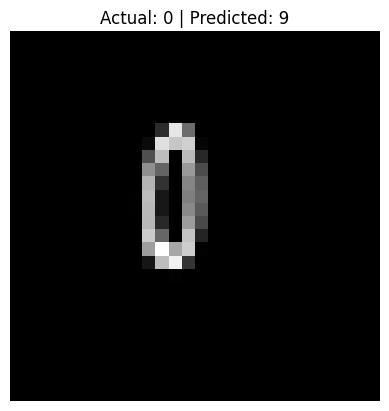

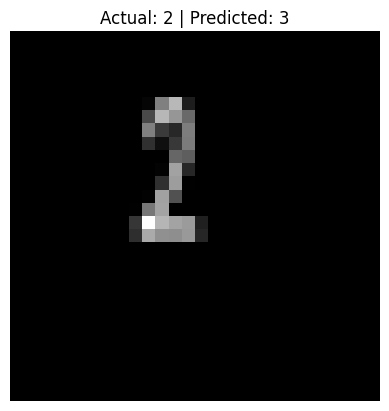

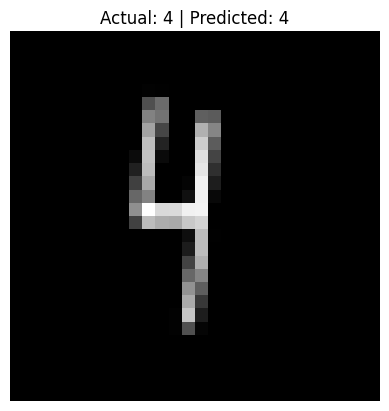

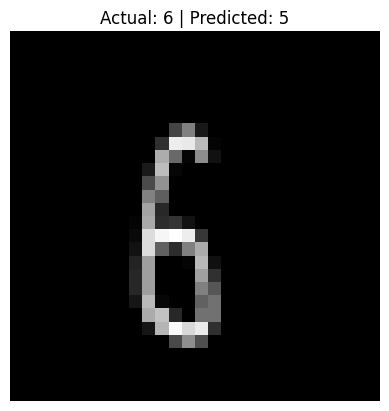

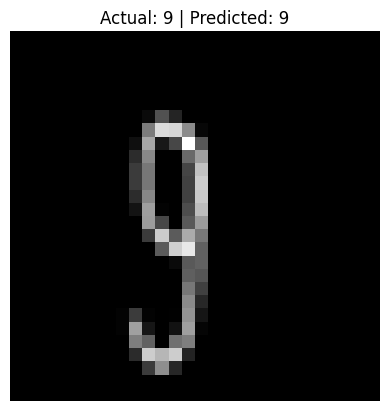

In [46]:
my_digits = {
    "handwritten-digits/digit_0.png": 0,
    "handwritten-digits/digit_2.png": 2,
    "handwritten-digits/digit_4.png": 4,
    "handwritten-digits/digit_6.png": 6,
    "handwritten-digits/digit_9.png": 9
}

loaded_cnn.eval()

for path, actual in my_digits.items():
    X = preprocess_image(path)

    with torch.no_grad():
        output = loaded_cnn(X.unsqueeze(0).to(device))
        prediction = output.argmax(1).item()

    plt.imshow(X.squeeze(), cmap="gray")
    plt.title(f"Actual: {actual} | Predicted: {prediction}")
    plt.axis("off")
    plt.show()

### Custom Image Results

| Actual | Predicted | Correct |
|---|---|---|
| 0 | 9 | No |
| 2 | 3 | No |
| 4 | 4 | Yes |
| 6 | 5 | No |
| 9 | 9 | Yes |

The CNN correctly predicted 2 out of 5 custom handwritten digits (40%).

The model performed much better on MNIST than on my own handwriting. One possible reason is that my images have different digit sizes, positions and drawing styles compared to MNIST.

I will try improving the preprocessing without retraining the model.

## 16. Improved Custom Image Preprocessing

The first custom image test reached 40% accuracy. I will improve the preprocessing by cropping the empty background, resizing the digit and centering it on a 28x28 canvas.

I will use the same trained CNN and the same 5 images to compare the results.

In [48]:
from PIL import Image, ImageOps

def preprocess_better(path):
    img = Image.open(path).convert("L")
    img = ImageOps.invert(img)

    # Remove empty background
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)

    # Resize while keeping the digit shape
    w, h = img.size
    scale = 20 / max(w, h)

    new_w = max(1, round(w * scale))
    new_h = max(1, round(h * scale))

    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # Center the digit
    canvas = Image.new("L", (28, 28), 0)

    x = (28 - new_w) // 2
    y = (28 - new_h) // 2

    canvas.paste(img, (x, y))

    return transforms.ToTensor()(canvas)

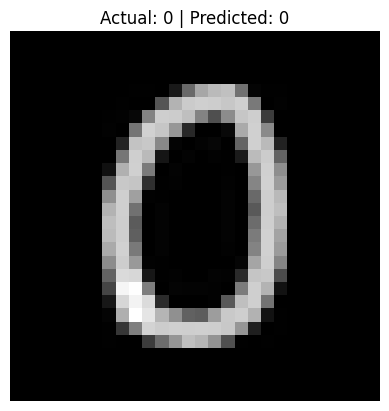

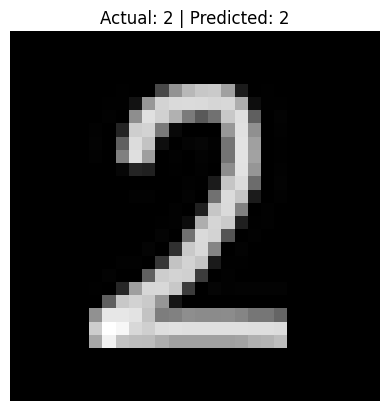

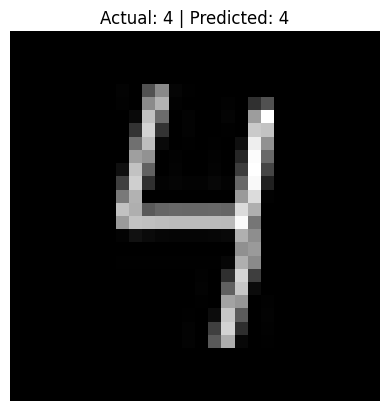

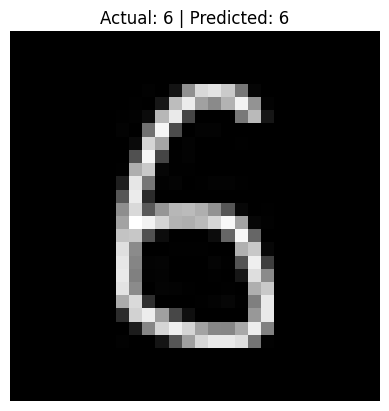

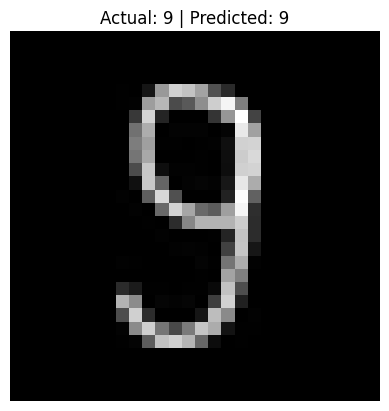

Custom Accuracy: 5/5


In [49]:
correct = 0

loaded_cnn.eval()

for path, actual in my_digits.items():
    X = preprocess_better(path)

    with torch.no_grad():
        output = loaded_cnn(X.unsqueeze(0).to(device))
        prediction = output.argmax(1).item()

    correct += prediction == actual

    plt.imshow(X.squeeze(), cmap="gray")
    plt.title(f"Actual: {actual} | Predicted: {prediction}")
    plt.axis("off")
    plt.show()

print(f"Custom Accuracy: {correct}/{len(my_digits)}")

### Improved Preprocessing Results

| Test | Correct Predictions | Accuracy |
|---|---:|---:|
| Original preprocessing | 2/5 | 40% |
| Improved preprocessing | 5/5 | 100% |

The first test correctly classified only 2 out of 5 handwritten digits.

After cropping the empty background, resizing the digits while keeping their aspect ratio, and centering them on a 28x28 canvas, the CNN correctly classified all 5 images.

The model was not retrained. This shows that preprocessing can strongly affect predictions on real handwritten images.

However, 5 images are a very small sample, so this result does not mean the model will achieve 100% accuracy on all real handwriting.

## 17. Visualize CNN Filters

I will visualize the learned filters from the first convolutional layer to see what patterns the CNN learned during training.

Filter shape: torch.Size([32, 1, 3, 3])


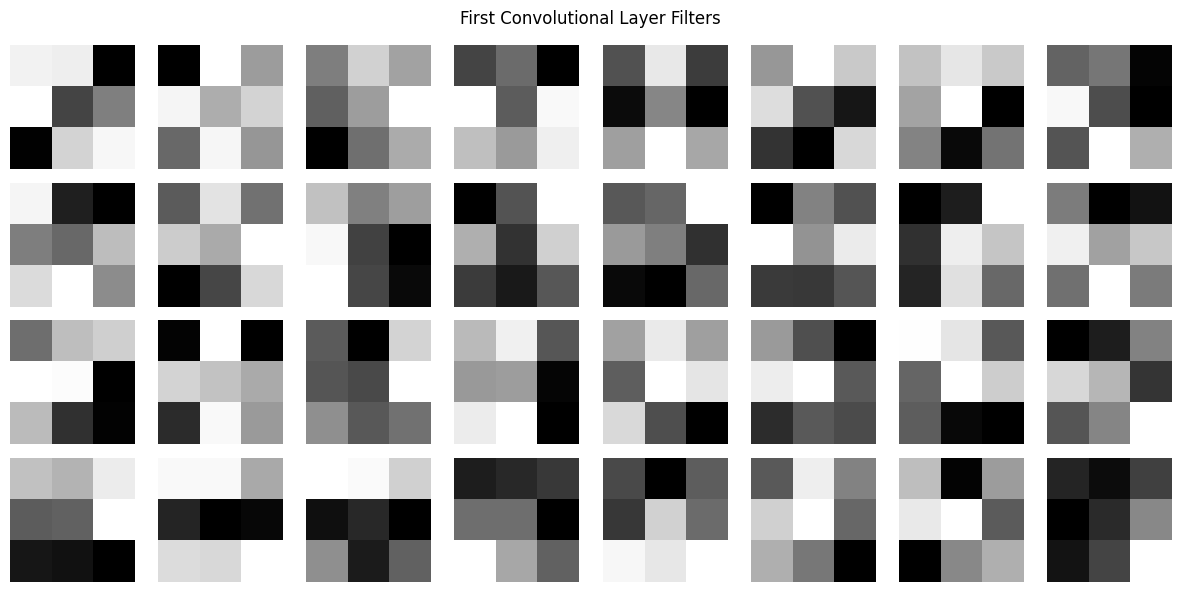

In [50]:
filters = loaded_cnn.conv1.weight.detach().cpu()

print("Filter shape:", filters.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.axis("off")

plt.suptitle("First Convolutional Layer Filters")
plt.tight_layout()
plt.show()

### Filter Visualization Results

The first convolutional layer contains 32 learned filters of size 3x3.

These filters have different weight patterns that can help detect simple visual features such as edges and lines.

The filters were learned during training from random initialization, without using pretrained weights.

## 18. Data Augmentation

I will train another CNN using small rotations and shifts to make the training images more varied.

I will compare its validation accuracy with the original CNN. Both models will use the same architecture, data split, learning rate and number of epochs.

In [51]:
from torch.utils.data import Subset

aug_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor()
])

aug_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=aug_transform
)

aug_train_ds = Subset(aug_data, train_ds.indices)

aug_train_loader = DataLoader(
    aug_train_ds,
    batch_size=64,
    shuffle=True
)

print("Augmented training images:", len(aug_train_ds))

Augmented training images: 54000


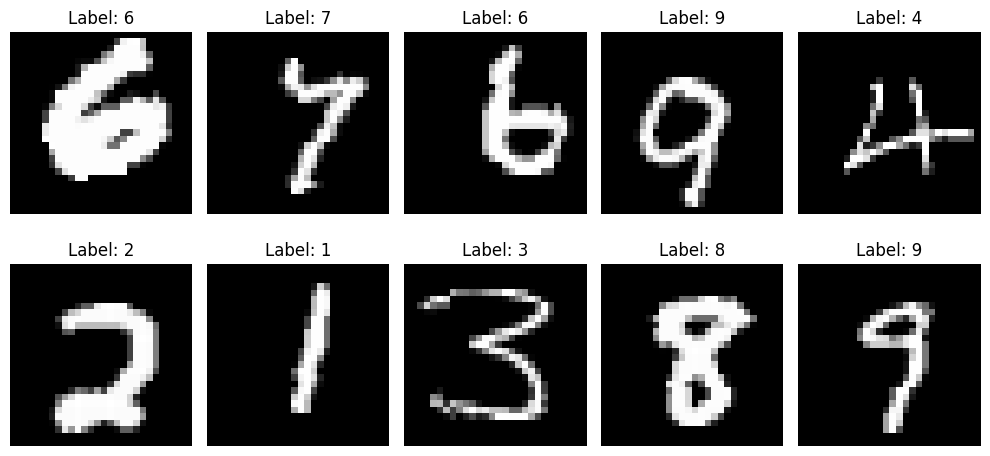

In [52]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    X, y = aug_train_ds[i]

    ax.imshow(X.squeeze(), cmap="gray")
    ax.set_title(f"Label: {y}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 19. Train CNN with Augmentation

I will train a new CNN using augmented training images. I will keep the validation data unchanged and use the same 5 epochs, learning rate and optimizer as the original CNN.

In [54]:
torch.manual_seed(42)

aug_cnn = CNN().to(device)

aug_optimizer = torch.optim.Adam(aug_cnn.parameters(), lr=lr)

aug_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

In [55]:
for epoch in range(epochs):

    aug_cnn.train()

    train_loss = 0
    train_correct = 0

    for X, y in aug_train_loader:
        X, y = X.to(device), y.to(device)

        aug_optimizer.zero_grad()

        output = aug_cnn(X)
        loss = loss_fn(output, y)

        loss.backward()
        aug_optimizer.step()

        train_loss += loss.item() * X.size(0)
        train_correct += (output.argmax(1) == y).sum().item()

    train_loss /= len(aug_train_ds)
    train_acc = train_correct / len(aug_train_ds)

    aug_cnn.eval()

    val_loss = 0
    val_correct = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)

            output = aug_cnn(X)
            loss = loss_fn(output, y)

            val_loss += loss.item() * X.size(0)
            val_correct += (output.argmax(1) == y).sum().item()

    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)

    aug_history["train_loss"].append(train_loss)
    aug_history["train_acc"].append(train_acc)
    aug_history["val_loss"].append(val_loss)
    aug_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.3790 | Train Acc: 0.8771 | Val Loss: 0.0946 | Val Acc: 0.9708
Epoch 2/5 | Train Loss: 0.1117 | Train Acc: 0.9655 | Val Loss: 0.0504 | Val Acc: 0.9853
Epoch 3/5 | Train Loss: 0.0826 | Train Acc: 0.9741 | Val Loss: 0.0510 | Val Acc: 0.9840
Epoch 4/5 | Train Loss: 0.0672 | Train Acc: 0.9787 | Val Loss: 0.0423 | Val Acc: 0.9867
Epoch 5/5 | Train Loss: 0.0585 | Train Acc: 0.9820 | Val Loss: 0.0412 | Val Acc: 0.9882


## 20. Compare CNN With and Without Augmentation

I will compare the validation accuracy of the original CNN and the CNN trained with augmented images.

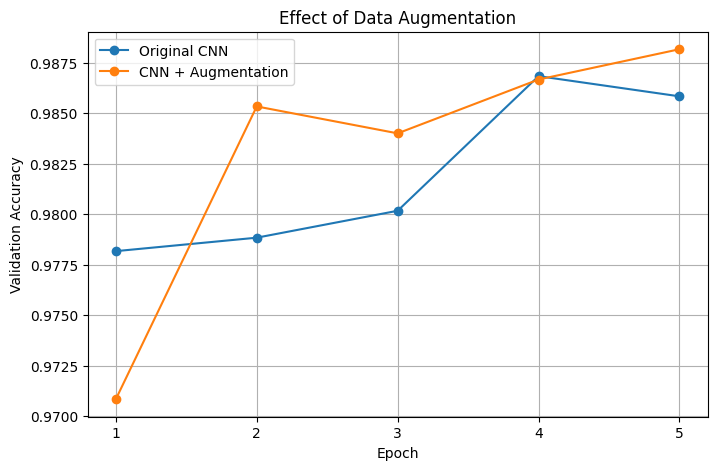

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    cnn_history["val_acc"],
    marker="o",
    label="Original CNN"
)

plt.plot(
    range(1, epochs + 1),
    aug_history["val_acc"],
    marker="o",
    label="CNN + Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Data Augmentation")
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True)
plt.show()

### Augmentation Results

The original CNN reached 98.58% final validation accuracy, while the augmented CNN reached 98.82%.

Data augmentation improved the final validation accuracy by 0.24 percentage points.

The augmented model also had lower final validation loss (0.0412 compared to 0.0529).

Small rotations and shifts may help the CNN recognize digits in slightly different positions and orientations. However, the improvement is small, and one training run is not enough to conclude that augmentation will always improve performance.

## 21. Augmented CNN Test Evaluation

In [58]:
aug_test_loss, aug_test_acc = evaluate(aug_cnn, test_loader)

print(f"Augmented CNN Test Loss: {aug_test_loss:.4f}")
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.2%}")

Augmented CNN Test Loss: 0.0298
Augmented CNN Test Accuracy: 99.01%


## 22. Final Results

This table summarizes the main results of the project.

In [59]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "MLP", "CNN + Augmentation"],
    "Final Validation Accuracy": [
        cnn_history["val_acc"][-1],
        mlp_history["val_acc"][-1],
        aug_history["val_acc"][-1]
    ],
    "Test Accuracy": [
        cnn_test_acc,
        mlp_test_acc,
        aug_test_acc
    ]
})

results

,Model,Final Validation Accuracy,Test Accuracy
0,CNN,0.985833,0.9882
1,MLP,0.966833,0.9731
2,CNN + Augmentation,0.988167,0.9901


## 23. Conclusion

I trained a CNN and an MLP from scratch on the MNIST dataset using the same data splits and training settings.

The original CNN achieved 98.82% test accuracy, while the MLP achieved 97.31%. The CNN performed better on this test because convolutional layers can learn local visual patterns in images.

The most common CNN confusion was predicting digit 8 as 9, which happened 10 times.

On my 5 handwritten images, the CNN initially achieved 40% accuracy. After improving the image preprocessing, it correctly predicted all 5 digits without retraining.

I also visualized the first convolutional layer filters and tested data augmentation. The augmented CNN achieved 99.01% test accuracy, compared to 98.82% for the original CNN.

These experiments showed me that model architecture, data augmentation and image preprocessing can all affect classification results.